# Spam Message Detection

## Exploratory Data Analysis (EDA)



In [133]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [134]:
# Load the dataset
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [135]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Dataset Overview

In [136]:
df.shape

(5572, 5)

## 4. Dataset Information

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


## 5. Missing Values Analysis

In [138]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## 6. Check Duplicate Records

In [139]:
df.duplicated().sum()

np.int64(403)

## 7. Display Column Names

In [140]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

## 8. Target Variable Distribution

In [141]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

## 9. Visualize Target Variable Distribution

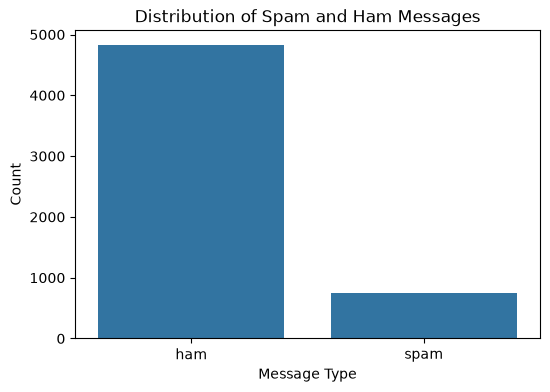

In [142]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="v1")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

# Data Cleaning

## 10. Remove Unnecessary Columns

In [143]:
# Remove unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [144]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 11. Rename Columns

In [145]:
# Rename columns
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

In [146]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 12. Remove Duplicate Messages

In [147]:
df = df.drop_duplicates()

In [148]:
df.shape

(5169, 2)

In [149]:
df.duplicated().sum()

np.int64(0)

## 13. Final Dataset Check

In [150]:
df.info()


<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5169 non-null   str  
 1   message  5169 non-null   str  
dtypes: str(2)
memory usage: 121.1 KB


In [151]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [152]:
df.isnull().sum()

label      0
message    0
dtype: int64

# Text Preprocessing

## 14. Convert Text to Lowercase

In [153]:
# Convert messages to lowercase
df["message"] = df["message"].str.lower()

In [154]:
df["message"]

0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                will ì_ b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: message, Length: 5169, dtype: str

In [155]:
df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## 16. Remove URLs

In [156]:
import re

# Function to remove URLs
def remove_urls(text):
    return re.sub(r"https?://\S+|www\.\S+", "", text)

## 17. Test URL Removal Function

In [157]:
sample = "Visit https://google.com now and www.facebook.com for more information."

print("Before:")
print(sample)

print("\nAfter:")
print(remove_urls(sample))

Before:
Visit https://google.com now and www.facebook.com for more information.

After:
Visit  now and  for more information.


## 18. Apply URL Removal to Dataset

In [158]:
# Apply URL removal function to all messages
df["message"] = df["message"].apply(remove_urls)

In [159]:
df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## 19. Remove Numbers

In [160]:
# Function to remove numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

## 20. Test Number Removal Function

In [161]:
sample = "Win 1000 dollars in 2 days."

print("Before:")
print(sample)

print("\nAfter:")
print(remove_numbers(sample))

Before:
Win 1000 dollars in 2 days.

After:
Win  dollars in  days.


## 21. Apply Number Removal to Dataset

In [162]:
df["message"] = df["message"].apply(remove_numbers)

In [163]:
df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## 22. Remove Punctuation

In [164]:
import string 
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


## 23. Create Punctuation Removal Function

In [165]:
# Function to remove punctuation
def remove_punctuation(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, "")
    return text

## 24. Test Punctuation Removal Function

In [166]:
sample = "Hello!!! How are you? I'm fine."

print("Before:")
print(sample)

print("\nAfter:")
print(remove_punctuation(sample))

Before:
Hello!!! How are you? I'm fine.

After:
Hello How are you Im fine


## 25. Apply Punctuation Removal to Dataset

In [167]:
# Apply punctuation removal function to all messages
df["message"] = df["message"].apply(remove_punctuation)

In [168]:
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


## 26. Remove Extra Spaces

In [169]:
# Function to remove extra spaces
def remove_extra_spaces(text):
    return " ".join(text.split())

## 27. Test Extra Space Removal Function

In [170]:
sample = "Hello       world    how   are     you"

print("Before:")
print(sample)

print("\nAfter:")
print(remove_extra_spaces(sample))

Before:
Hello       world    how   are     you

After:
Hello world how are you


In [171]:
# Apply extra space removal function to all messages
df["message"] = df["message"].apply(remove_extra_spaces)

In [172]:
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


## 29. Tokenization

In [173]:
from nltk.tokenize import word_tokenize
import nltk

In [174]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to C:\Users\safier
[nltk_data]     mool\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\safier
[nltk_data]     mool\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 31. Create Tokenization Function

In [175]:
# Function to tokenize text
def tokenize_text(text):
    return word_tokenize(text)

## 32. Test Tokenization Function

In [176]:
sample = "machine learning is amazing"

tokens = tokenize_text(sample)

print("Original Text:")
print(sample)

print("\nTokens:")
print(tokens)

Original Text:
machine learning is amazing

Tokens:
['machine', 'learning', 'is', 'amazing']


## 33. Stopwords Removal

In [177]:
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\safier
[nltk_data]     mool\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [178]:
stop_words = set(stopwords.words("english"))

print(stop_words)

{'few', 'nor', 'will', 'at', "she'll", 'd', 'their', "we'll", 'after', "it's", "you've", 'in', 'where', "that'll", "i've", "couldn't", 'can', 'that', 'they', 'are', 'did', 'about', "aren't", 'it', 'over', 'those', 'how', 'wouldn', 'themselves', "they'd", "haven't", 'should', 'be', 'the', 'being', 'do', 'same', "needn't", "they're", 'on', 'our', 'and', "shouldn't", 'most', 'having', 'she', 'but', "they've", 'herself', 'her', 'out', "we'd", "you'll", 'ma', 'such', 'further', 'only', 'll', 'down', 'when', 'all', "didn't", 'if', "we've", 'off', 'he', 'hers', 'your', 'with', 't', "i'd", 'under', "it'll", 'for', 'once', 'because', 'yours', 'here', 'other', 're', "wouldn't", 'shouldn', "don't", 'before', "you're", 'm', 'ours', 'hasn', 'up', 'yourself', 'any', "mustn't", 'very', 'own', 'o', "isn't", 'some', "she'd", 'we', 'while', 'y', 'each', 'then', 'his', 'not', 'does', 'just', 'theirs', 'itself', 'who', 'haven', 'doesn', 'wasn', 'both', 'have', "he'd", 'as', 'were', 'below', 'didn', 'whom'

In [179]:
# Function to remove stopwords
def remove_stopwords(tokens):
    filtered_tokens = []

    for word in tokens:
        if word not in stop_words:
            filtered_tokens.append(word)

    return filtered_tokens

## 35. Test Stopwords Removal

In [180]:
sample = "i love machine learning"

tokens = tokenize_text(sample)

print("Before:")
print(tokens)

print("\nAfter:")
print(remove_stopwords(tokens))

Before:
['i', 'love', 'machine', 'learning']

After:
['love', 'machine', 'learning']


In [181]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [182]:
print(stemmer.stem("playing"))
print(stemmer.stem("played"))
print(stemmer.stem("plays"))
print(stemmer.stem("studies"))
print(stemmer.stem("studying"))

play
play
play
studi
studi


## 37. Create Stemming Function

In [183]:
# Function to stem tokens
def stem_tokens(tokens):
    stemmed_tokens = []

    for word in tokens:
        stemmed_tokens.append(stemmer.stem(word))

    return stemmed_tokens

## 38. Test Stemming Function

In [184]:
sample = ["playing", "studies", "learning"]

print("Before:")
print(sample)

print("\nAfter:")
print(stem_tokens(sample))

Before:
['playing', 'studies', 'learning']

After:
['play', 'studi', 'learn']


## 39. Build Complete Text Cleaning Pipeline

In [185]:
# Complete text preprocessing pipeline
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = remove_urls(text)

    # Remove numbers
    text = remove_numbers(text)

    # Remove punctuation
    text = remove_punctuation(text)

    # Remove extra spaces
    text = remove_extra_spaces(text)

    # Tokenization
    tokens = tokenize_text(text)

    # Remove stopwords
    tokens = remove_stopwords(tokens)

    # Stemming
    tokens = stem_tokens(tokens)

    # Convert tokens back to text
    text = " ".join(tokens)

    return text

## 40. Test Complete Pipeline

In [186]:
sample = "Visit https://google.com now! I am playing football with 2 friends."

print("Before:")
print(sample)

print("\nAfter:")
print(clean_text(sample))


Before:
Visit https://google.com now! I am playing football with 2 friends.

After:
visit play footbal friend


## 41. Apply Text Cleaning Pipeline

In [187]:
df["message"] = df["message"].apply(clean_text)

In [188]:
df.head()

,label,message
0,ham,go jurong point crazi avail bugi n great world...
1,ham,ok lar joke wif u oni
2,spam,free entri wkli comp win fa cup final tkt st m...
3,ham,u dun say earli hor u c alreadi say
4,ham,nah dont think goe usf live around though


## 42. TF-IDF Vectorization

In [189]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [190]:
tfidf = TfidfVectorizer()

## 43. Convert Text to TF-IDF Features

In [191]:
X = tfidf.fit_transform(df["message"])
print(X.shape)
type(X)

(5169, 7047)


scipy.sparse._csr.csr_matrix

## 44. Create Features and Labels

In [192]:
y = df["label"]

In [193]:
print(y.head())

0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: str


In [194]:
print("hello world")
print("gog aipvz i")

hello world
gog aipvz i


## 45 Label Encoding 

In [195]:
y = df["label"].map({"ham":0 ,"spam":1})

In [196]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

## 46 Train Test Split 

In [197]:
from sklearn.model_selection import train_test_split

In [198]:
X_train , X_test ,y_train,y_test=train_test_split(X,y ,test_size=0.2,random_state= 42 ,stratify=y)

In [199]:
print("X_train :",X_train.shape)
print("X_test :",X_test.shape)
print("y_train :",y_train.shape)
print("y_test:",y_test.shape)






X_train : (4135, 7047)
X_test : (1034, 7047)
y_train : (4135,)
y_test: (1034,)


In [200]:
print(y_train.value_counts())
print(y_test.value_counts())

label
0    3613
1     522
Name: count, dtype: int64
label
0    903
1    131
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

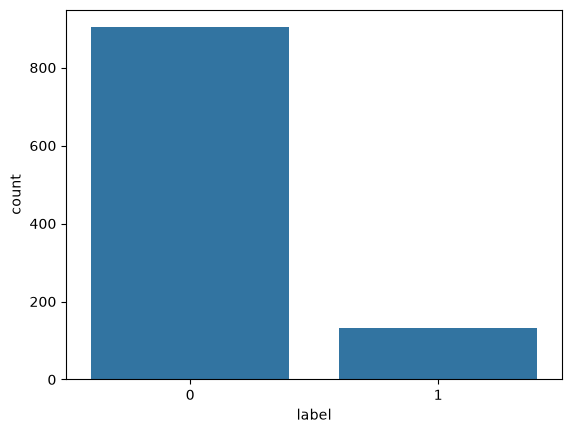

In [201]:
sns.countplot(data = df ,x= y_test)


<Axes: xlabel='label', ylabel='count'>

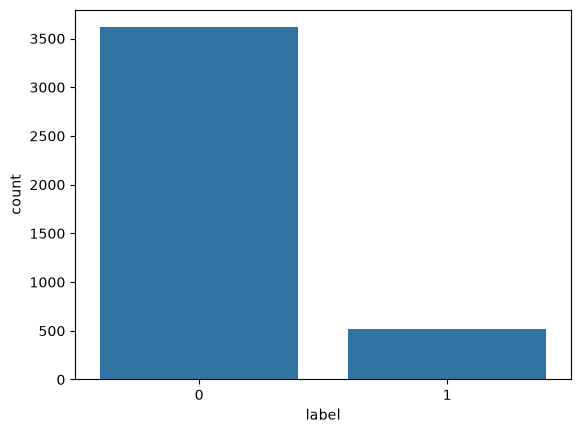

In [202]:
sns.countplot(data = df ,x= y_train)

## 47. Train Logistic Regression Model

In [203]:
from sklearn.linear_model import LogisticRegression

In [204]:
model = LogisticRegression()

## 48. Train the Model

In [205]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 49. Predict on Test Data

In [206]:
y_pred = model.predict(X_test)

In [207]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [208]:
print(np.unique(y_pred))
print(y_pred.shape)

[0 1]
(1034,)


## 50. Model Evaluation

In [209]:
from sklearn.metrics import accuracy_score

In [210]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9564796905222437
Accuracy: 0.9565


In [211]:
from sklearn.metrics import classification_report

In [212]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       903
           1       1.00      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.98      0.83      0.88      1034
weighted avg       0.96      0.96      0.95      1034



## 51. Confusion Matrix

In [213]:
from sklearn.metrics import confusion_matrix

In [214]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[903   0]
 [ 45  86]]


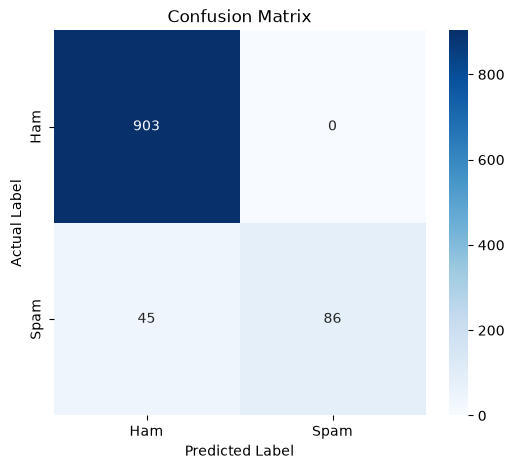

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [216]:
from sklearn.naive_bayes import MultinomialNB

In [217]:
nb_model = MultinomialNB()

In [218]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7047)","[[0.33,1.35,0.1 ,...,0. ,1.61,0.4 ], [0. ,0. ,0. ,...,0.32,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7047)","[[-9.4 ,-8.82,-9.59,...,-9.68,-8.72,-9.34], [-9.09,-9.09,-9.09,...,-8.81,-9.09,-9.09]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7047


In [219]:
nb_pred = nb_model.predict(X_test)

In [220]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.9681


In [221]:
results = {
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy
    ]
}

In [222]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.956480
1,Multinomial Naive Bayes,0.968085


In [223]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Multinomial Naive Bayes,0.968085
0,Logistic Regression,0.956480


In [224]:
nb_cm = confusion_matrix(y_test, nb_pred)

print(nb_cm)

[[903   0]
 [ 33  98]]


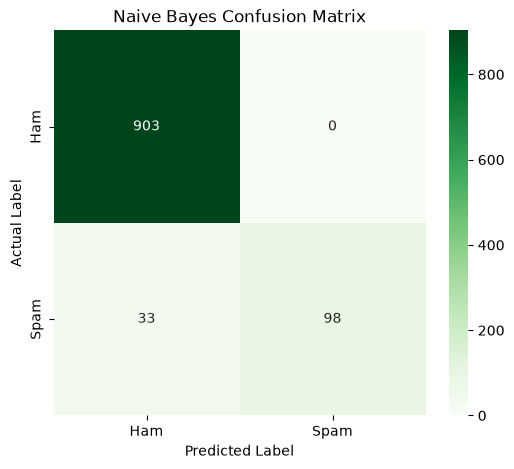

In [225]:
plt.figure(figsize=(6,5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [226]:
from sklearn.svm import LinearSVC

In [227]:
svm_model = LinearSVC(random_state=42)

In [228]:
svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [229]:
svm_pred = svm_model.predict(X_test)

In [230]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.9787


In [231]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.84      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [232]:
svm_cm = confusion_matrix(y_test, svm_pred)

print(svm_cm)

[[902   1]
 [ 21 110]]


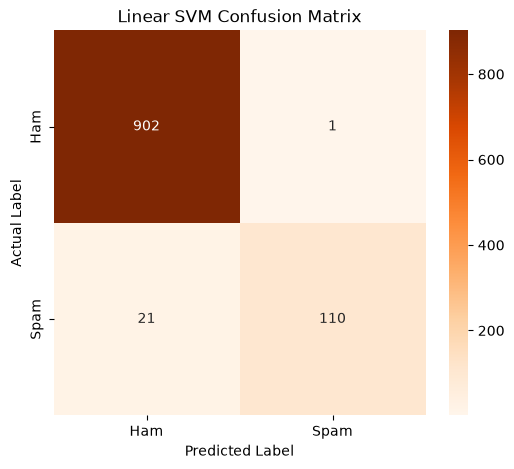

In [233]:
plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Linear SVM Confusion Matrix")

plt.show()

In [234]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [235]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [236]:
scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

In [237]:
print(scores)

[0.97969052 0.97582205 0.97678917 0.97485493 0.98354308]


In [238]:
print(f"Mean Accuracy: {scores.mean():.4f}")

Mean Accuracy: 0.9781


In [239]:
print(f"Standard Deviation: {scores.std():.4f}")

Standard Deviation: 0.0031


In [240]:
from sklearn.model_selection import GridSearchCV

In [241]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [242]:
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [243]:
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printe

In [244]:
print(grid_search.best_params_)

{'C': 10}


In [245]:
print(grid_search.best_score_)

0.9793004918913757


In [246]:
best_svm = LinearSVC(
    C=10,
    random_state=42
)

In [247]:
best_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adju

In [248]:
best_pred = best_svm.predict(X_test)

In [249]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [250]:
best_cm = confusion_matrix(y_test, best_pred)

print(best_cm)

[[899   4]
 [ 17 114]]


In [251]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Optimized Linear SVM"
    ],
    "Accuracy": [
        0.9555,
        0.9681,
        0.9787,
        0.9807
    ],
    "Spam Precision": [
        1.00,
        1.00,
        0.99,
        0.97
    ],
    "Spam Recall": [
        0.65,
        0.75,
        0.84,
        0.88
    ],
    "Spam F1-score": [
        0.79,
        0.86,
        0.91,
        0.92
    ]
})

comparison

,Model,Accuracy,Spam Precision,Spam Recall,Spam F1-score
0,Logistic Regression,0.9555,1.00,0.65,0.79
1,Naive Bayes,0.9681,1.00,0.75,0.86
2,Linear SVM,0.9787,0.99,0.84,0.91
3,Optimized Linear SVM,0.9807,0.97,0.88,0.92


In [252]:
import joblib


In [253]:
joblib.dump(
    best_svm,
    "svm_model.pkl"
)

['svm_model.pkl']

In [254]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [255]:
import os

print(os.listdir())

['eda.ipynb', 'svm_model.pkl', 'tfidf_vectorizer.pkl']


In [256]:
loaded_model = joblib.load("svm_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

In [257]:
message = [
    "Congratulations! You have won a free iPhone. Click here to claim now!"
]

In [258]:
message_vector = loaded_tfidf.transform(message)

In [259]:
prediction = loaded_model.predict(message_vector)

In [260]:
print(prediction)

[1]


In [261]:
if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam
